In [1]:
!pip install geopandas

In [4]:
import geopandas as gpd
print(gpd.__version__)

1.1.4


In [12]:
import os
import re
import rasterio
from rasterio.windows import Window

# Bounding Box labelling for YOLO Object Detection
def label_existing_tiles(jpg_dir , rgb_path , shapefile_path,label_dir,tile_size = 640,class_id = 0, min_box_frac = 0.05):
    
    # creating YOLO bounding box labels by matching shapefile polygons to tiles
    os.makedirs(label_dir,exist_ok = True)
    gdf = gpd.read_file(shapefile_path) # load ridge and furrow polygons
    gdf = gdf[gdf.geometry.notnull()] 
    features = list(gdf.geometry)    # extract shape
    pattern = re.compile(r"tile_(\d+)_(\d+)\.jpg$") # extract tile position (top ,  left ) filename

    tiles_checked= 0
    tiles_labels = 0
    skipped = 0

    with rasterio.open(rgb_path) as ds:
        for tile in os.listdir(jpg_dir):
            m = pattern.match(tile)
            if not m:
                skipped +=1
                continue
            top,left = int(m.group(1)),int(m.group(2))


            # get geographic bounds of this tile
            window = Window(left,top,tile_size , tile_size)
            win_transform = ds.window_transform(window)
            minx  , maxy = win_transform*(0,0)   # top left corner in map coordinate
            maxx, miny = win_transform*(tile_size , tile_size)  # bottom right corner
            px_res = win_transform.a           # pixel width in map units
            py_res = -win_transform.e         #pixel height in map units


            boxes = []
            for geom in features:
                # check if polygon overlaps this file
                gminx , gminy , gmaxx, gmaxy = geom.bounds
                if gmaxx < minx or gminx > maxx or gmaxy < miny or gminy > maxy:
                    continue # no overlap 

                # clip polygon bounds to tile boundary
                clip_minx = max(gminx, minx)
                clip_maxx = min(gmaxx , maxx)
                clip_miny = max(gminy , miny)
                clip_maxy = min(gmaxy , maxy)

                if clip_maxx <= clip_minx or clip_maxy <= clip_miny:
                    continue # skip no valid area after clipping


                # covert map coordinates to pixel coordinate 
                px_min = (clip_minx - minx)/px_res
                px_max = (clip_maxx - minx)/px_res
                py_min = (maxy-clip_maxy)/py_res
                py_max = (maxy-clip_miny)/ py_res

                # calculate bounding box centre and dimensions
                box_w = px_max - px_min
                box_h = py_max- py_min
                box_cx = px_min + box_w /2
                box_cy = py_min + box_h /2


                # Normalise to 0-1  for yolo format
                norm_cx = box_cx / tile_size
                norm_cy = box_cy / tile_size
                norm_w = box_w / tile_size
                norm_h = box_h / tile_size

                # skip boxes if they are too small 
                if norm_w < min_box_frac or norm_h < min_box_frac:
                    continue

                boxes.append((class_id , norm_cx,norm_cy , norm_w, norm_h))
            tiles_checked +=1

            # save label file if tile contains any features

            if boxes:
                tile_name = tile.replace(".jpg","")
                txt_path = os.path.join(label_dir,tile_name + ".txt")
                with open(txt_path, "w") as f:
                    for cid,cx,cy,w,h in boxes:
                        f.write(f"{cid} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
                tiles_labels +=1
                          
    # print Summary
    print(f"Tiles checked:{tiles_checked}")
    print(f" Tiles with labels : {tiles_labels}")
    print(f" Background/ empty tile (no label files):{tiles_checked-tiles_labels}")
    if skipped:
        print(f" Skipped {skipped} file that didn't match jpg pattern")
    return tiles_checked, tiles_labels

    

In [14]:
import shutil
import os
label_dir = "/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg_labels_for_yolo_bounding_box"

if os.path.exists(label_dir):
    shutil.rmtree(label_dir)
tiles_checked, tiles_labels = label_existing_tiles(
    jpg_dir="/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg",
    rgb_path="/Users/rajkamal0raon/Desktop/dataset1/full_site_RGB1.tif",
    shapefile_path="/Users/rajkamal0raon/Downloads/dataset/rnf_sites.shp",
    label_dir=label_dir,
    tile_size=640,
    class_id=0,
    min_box_frac=0.05,
)

Tiles checked:1600
 Tiles with labels : 1092
 Background/ empty tile (no label files):508


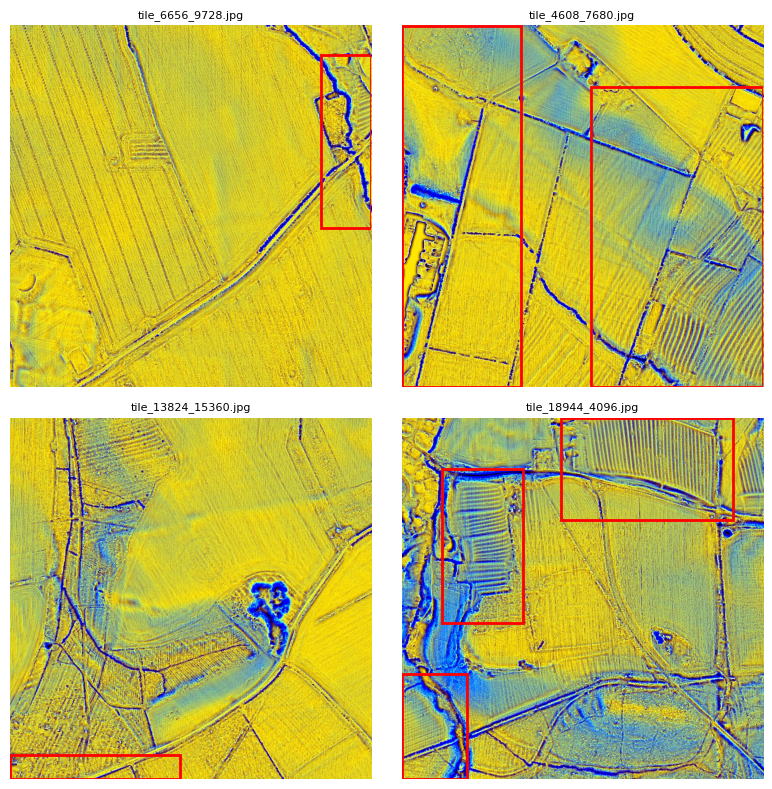

In [2]:
# To see  label images 

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image 
import os 
import random

jpg_dir = "/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg"
label_dir = "/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg_labels_for_yolo_bounding_box"

# label files
label_files= os.listdir(label_dir)
samples = random.sample(label_files,4)


# show 4 images with bounding boxes
fig,axes = plt.subplots(2,2 , figsize = (8,8))
for ax, sample in zip(axes.flat,samples): # pairing each label with subplot
    tile_name = sample.replace(".txt",".jpg")
    img = Image.open(os.path.join(jpg_dir, tile_name))
    ax.imshow(img)


    # Draw red bounding boxes from label line
    with open(os.path.join(label_dir, sample)) as f:
        for line in f:
            cid , cx,cy, bw,bh = map(float , line.strip().split())
            x = (cx-bw/2)*640     # covert normalised to pixel coordinates
            y = (cy - bh/2)*640
            rect = patches.Rectangle((x,y),bw*640 , bh*640,
                                 linewidth = 2 , edgecolor = 'red',facecolor = 'none')
            ax.add_patch(rect)
    ax.set_title(tile_name , fontsize = 8)
    ax.axis("off")
        

plt.tight_layout()
plt.savefig('yolo_bounding_box',dpi = 300,bbox_inches = 'tight')
plt.show()




In [1]:
import shutil
shutil.make_archive(
    "/Users/rajkamal0raon/Desktop/dataset1/YOLO_Bounding_box_labelling",
    "zip",
    "/Users/rajkamal0raon/Desktop/dataset1/tiles_jpg_labels_for_yolo_bounding_box")
print("Zipped YOLO Bounding Box labelling")





Zipped YOLO Bounding Box labelling
